In [91]:
from google.colab import drive
drive.mount('/content/drive/')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = '/content/drive/MyDrive/abalone_original.csv'
df = pd.read_csv(url)
df

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,sex,length,diameter,height,whole-weight,shucked-weight,viscera-weight,shell-weight,rings
0,M,91,73,19,102.8,44.9,20.2,30.0,15
1,M,70,53,18,45.1,19.9,9.7,14.0,7
2,F,106,84,27,135.4,51.3,28.3,42.0,9
3,M,88,73,25,103.2,43.1,22.8,31.0,10
4,I,66,51,16,41.0,17.9,7.9,11.0,7
...,...,...,...,...,...,...,...,...,...
4172,F,113,90,33,177.4,74.0,47.8,49.8,11
4173,M,118,88,27,193.2,87.8,42.9,52.1,10
4174,M,120,95,41,235.2,105.1,57.5,61.6,9
4175,F,125,97,30,218.9,106.2,52.2,59.2,10


In [92]:
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

Dimensiones: 4177 filas × 9 columnas


In [93]:
df.describe()

,length,diameter,height,whole-weight,shucked-weight,viscera-weight,shell-weight,rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,104.798420,81.576251,27.903280,165.748432,71.873498,36.118722,47.766172,9.933684
std,24.018583,19.847973,8.365411,98.077804,44.392590,21.922850,27.840534,3.224169
min,15.000000,11.000000,0.000000,0.400000,0.200000,0.100000,0.300000,1.000000
25%,90.000000,70.000000,23.000000,88.300000,37.200000,18.700000,26.000000,8.000000
50%,109.000000,85.000000,28.000000,159.900000,67.200000,34.200000,46.800000,9.000000
75%,123.000000,96.000000,33.000000,230.600000,100.400000,50.600000,65.800000,11.000000
max,163.000000,130.000000,226.000000,565.100000,297.600000,152.000000,201.000000,29.000000


In [94]:
print(df.dtypes)
print()
print("Valores nulos por columna:")
print(df.isnull().sum())

sex                object
length              int64
diameter            int64
height              int64
whole-weight      float64
shucked-weight    float64
viscera-weight    float64
shell-weight      float64
rings               int64
dtype: object

Valores nulos por columna:
sex               0
length            0
diameter          0
height            0
whole-weight      0
shucked-weight    0
viscera-weight    0
shell-weight      0
rings             0
dtype: int64


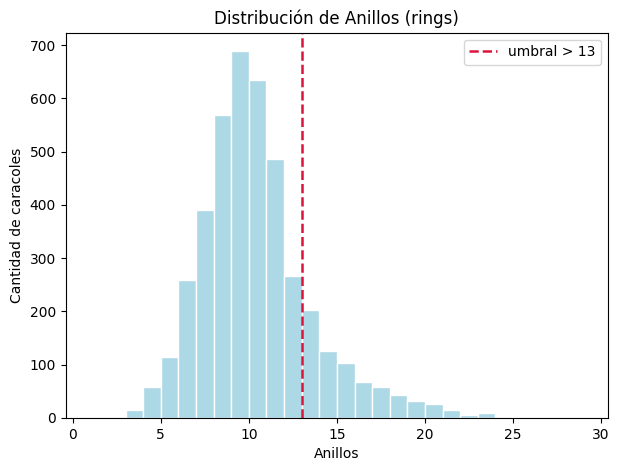

In [97]:
plt.figure(figsize=(7, 5))

# Histograma de rings
plt.hist(df['rings'], bins=28, color='lightblue', edgecolor='white')
plt.title('Distribución de Anillos (rings)')
plt.xlabel('Anillos')
plt.ylabel('Cantidad de caracoles')
plt.axvline(13, color='crimson', linestyle='--', linewidth=1.8, label='umbral > 13')
plt.legend()

plt.show()

In [98]:
feature_names_out = preprocessor.get_feature_names_out()

coeficientes = pd.DataFrame({
    'Variable': feature_names_out,
    'Coeficiente': lr.coef_[0]
})

coeficientes

,Variable,Coeficiente
0,num__length,-1.203216
1,num__diameter,1.282027
2,num__height,0.782609
3,num__whole-weight,2.232332
4,num__shucked-weight,-3.292100
5,num__viscera-weight,-0.481073
6,num__shell-weight,1.421376
7,cat__sex_F,-0.057461
8,cat__sex_I,-0.460940
9,cat__sex_M,-0.067145


In [99]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# --- Variable objetivo ---
df['old'] = (df['rings'] > 13).astype(int)
print("Distribución de la variable objetivo:")
print(df['old'].value_counts())


# --- Features y target ---
X = df.drop(columns=['rings', 'old'])
y = df['old']
# --- Separacion de variables categoricas y numericas ---
var_cat = ['sex']
var_num = [c for c in X.columns if c not in var_cat]
# --- separacion de los datos a proporciones iguales ---
X_train, X_test, y_train_original, y_test = train_test_split(X, y, test_size=0.20, random_state=24, stratify=y) # Changed y_train to y_train_original

print(f"Tamaño train : {X_train.shape[0]} muestras")
print(f"Tamaño test  : {X_test.shape[0]} muestras")

Distribución de la variable objetivo:
old
0    3687
1     490
Name: count, dtype: int64
Tamaño train : 3341 muestras
Tamaño test  : 836 muestras


In [100]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

all_evaluation_results = []

def plot_confusion_matrix(y_true, y_pred, title_suffix, model_name, sampling_strategy, set_type):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Old (0)', 'Old (1)'], yticklabels=['Not Old (0)', 'Old (1)'])
    plt.xlabel('Clase predicha')
    plt.ylabel('Clase real')
    plt.title(f'Matriz de Confusión: {model_name} ({sampling_strategy}) - {set_type} {title_suffix}')
    plt.show()

def record_metrics(model_name, sampling_strategy, set_type, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    all_evaluation_results.append({
        'Model': model_name,
        'Sampling': sampling_strategy,
        'Set': set_type,
        'Accuracy': accuracy,
        'Recall': recall,
        'F1 Score': f1
    })
    print(f"--- {model_name} ({sampling_strategy}) - {set_type} Set ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Ploteo de matriz de confusion
    plot_confusion_matrix(y_true, y_pred, '', model_name, sampling_strategy, set_type)

In [101]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, var_num),('cat', categorical_transformer, var_cat)])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Undersampling
rus = RandomUnderSampler(sampling_strategy='majority', random_state=24)
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train_processed, y_train_original)

print("Distribución de la variable objetivo después del undersampling en el conjunto de entrenamiento:")
print(pd.Series(y_train_undersampled).value_counts())

positive_count = pd.Series(y_train_undersampled).value_counts()[1]
negative_count = pd.Series(y_train_undersampled).value_counts()[0]

Distribución de la variable objetivo después del undersampling en el conjunto de entrenamiento:
old
0    392
1    392
Name: count, dtype: int64


--- Regresion Logistica (Solo) - Entrenamiento Set ---
Accuracy: 0.9009
Recall: 0.2908
F1 Score: 0.4079


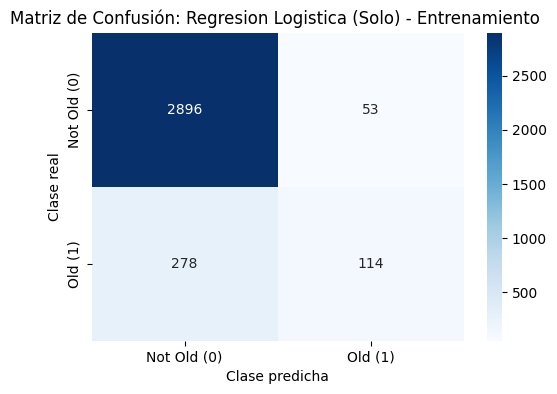

--- Regresion Logistica (Solo) - Test Set ---
Accuracy: 0.8983
Recall: 0.2551
F1 Score: 0.3704


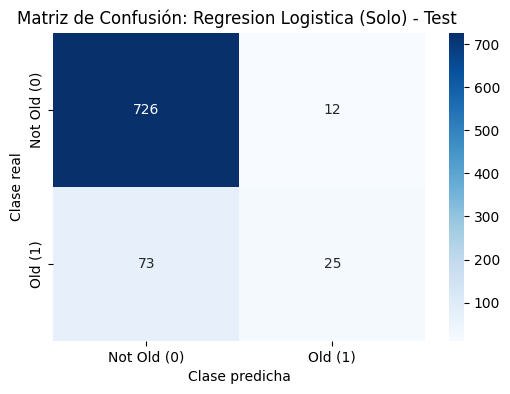

In [102]:
from sklearn.linear_model import LogisticRegression

# Entrenamiento del modelo sin ningun tratamiento al desbalanceo
lr_solo = LogisticRegression(random_state=24, solver='liblinear')
lr_solo.fit(X_train_processed, y_train_original)

y_pred_lr_solo_train = lr_solo.predict(X_train_processed)
y_pred_lr_solo_test = lr_solo.predict(X_test_processed)

# --- Metricas de rendimiento TRAIN (Solo) ---
record_metrics('Regresion Logistica', 'Solo', 'Entrenamiento', y_train_original, y_pred_lr_solo_train)
# --- Metricas de rendimiento TEST (Solo) ---
record_metrics('Regresion Logistica', 'Solo', 'Test', y_test, y_pred_lr_solo_test)

--- SVM (Solo) - Train Set ---
Accuracy: 0.8970
Recall: 0.1480
F1 Score: 0.2522


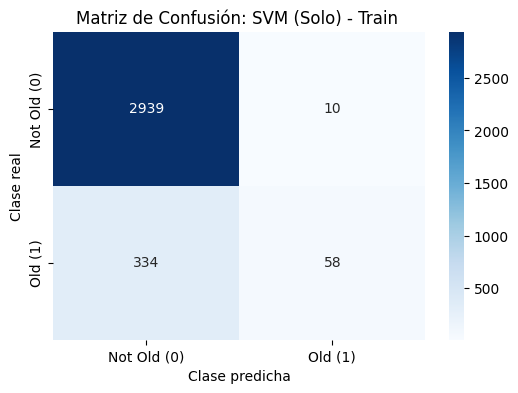

--- SVM (Solo) - Test Set ---
Accuracy: 0.8864
Recall: 0.1327
F1 Score: 0.2149


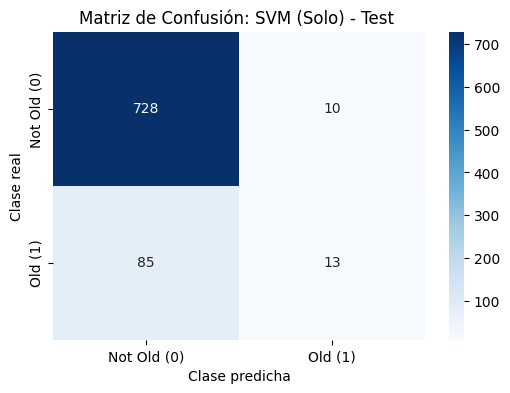

In [103]:
from sklearn.svm import SVC

# Entrenamientro del SVM sin balanceo
svm_solo = SVC(random_state=24)
svm_solo.fit(X_train_processed, y_train_original)

y_pred_svm_solo_train = svm_solo.predict(X_train_processed)
y_pred_svm_solo_test = svm_solo.predict(X_test_processed)

# --- Metricas de rendimiento TRAIN (Solo) ---
record_metrics('SVM', 'Solo', 'Train', y_train_original, y_pred_svm_solo_train)
# --- Metricas de rendimiento TEST (Solo) ---
record_metrics('SVM', 'Solo', 'Test', y_test, y_pred_svm_solo_test)



--- Random Forest (Solo) - Train Set ---
Accuracy: 1.0000
Recall: 1.0000
F1 Score: 1.0000


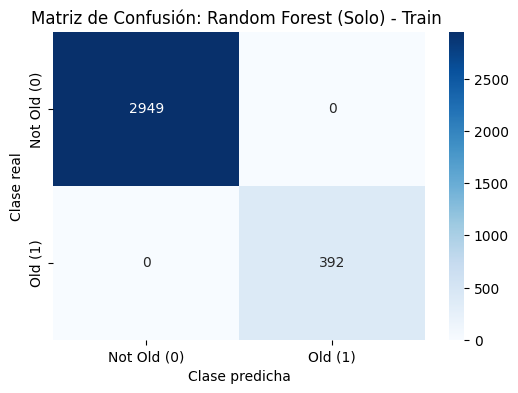

--- Random Forest (Solo) - Test Set ---
Accuracy: 0.8959
Recall: 0.2857
F1 Score: 0.3916


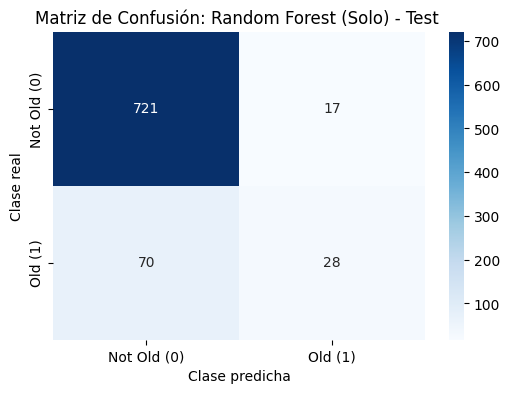

In [104]:
from sklearn.ensemble import RandomForestClassifier

# Entrenamiento del Random Forest sin balanceo
rf_solo = RandomForestClassifier(random_state=24)
rf_solo.fit(X_train_processed, y_train_original)

y_pred_rf_solo_train = rf_solo.predict(X_train_processed)
y_pred_rf_solo_test = rf_solo.predict(X_test_processed)

# --- Metricas de rendimiento TRAIN (Solo) ---
record_metrics('Random Forest', 'Solo', 'Train', y_train_original, y_pred_rf_solo_train)
# --- Metricas de rendimiento TEST (Solo) ---
record_metrics('Random Forest', 'Solo', 'Test', y_test, y_pred_rf_solo_test)

In [105]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=24, solver='liblinear')
lr.fit(X_train_undersampled, y_train_undersampled) # Usando undersampling

LogisticRegression(random_state=24, solver='liblinear')

--- Logistic Regression (Undersampling) - Train Set ---
Accuracy: 0.7857
Recall: 0.7755
F1 Score: 0.7835


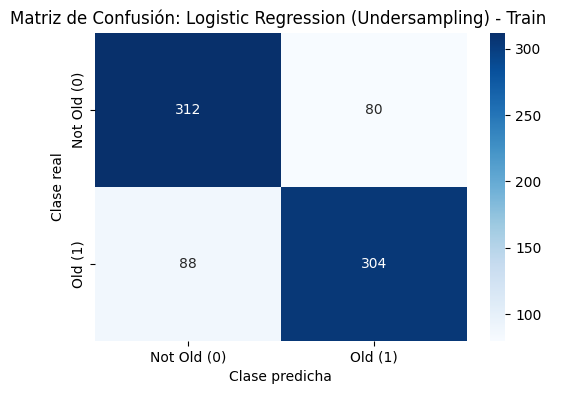

--- Logistic Regression (Undersampling) - Test Set ---
Accuracy: 0.8242
Recall: 0.8367
F1 Score: 0.5273


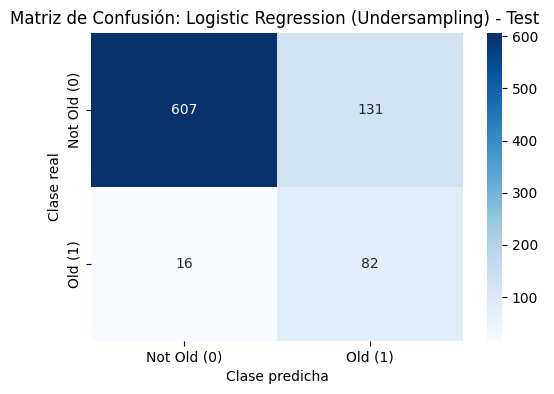

In [106]:
from sklearn.linear_model import LogisticRegression

# Predict on test and train sets
y_pred_lr_us_test = lr.predict(X_test_processed)
y_pred_lr_us_train = lr.predict(X_train_undersampled)

# --- Metricas de rendimiento TRAIN (Undersampling) ---
record_metrics('Logistic Regression', 'Undersampling', 'Train', y_train_undersampled, y_pred_lr_us_train)
# --- Metricas de rendimiento TEST (Undersampling) ---
record_metrics('Logistic Regression', 'Undersampling', 'Test', y_test, y_pred_lr_us_test)

In [108]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# Usando Oversampling
ros = RandomOverSampler(sampling_strategy='minority', random_state=24)
X_train_oversampled, y_train_oversampled = ros.fit_resample(X_train_processed, y_train_original)

--- Logistic Regression (Oversampling) - Train Set ---
Accuracy: 0.7923
Recall: 0.7704
F1 Score: 0.7877


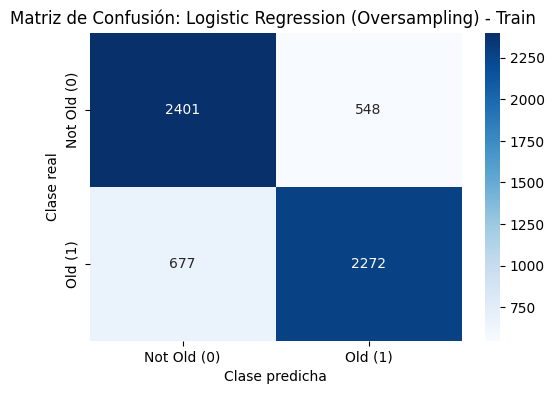

--- Logistic Regression (Oversampling) - Test Set ---
Accuracy: 0.8361
Recall: 0.8673
F1 Score: 0.5537


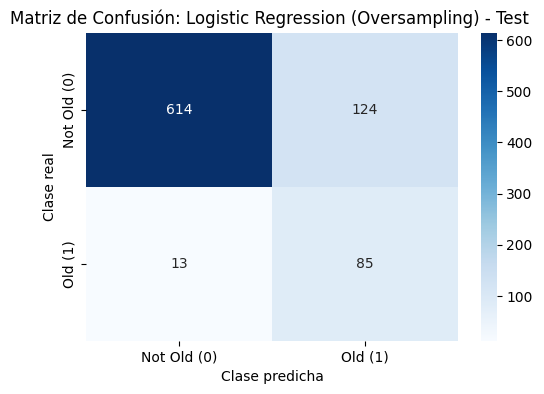

In [109]:
from sklearn.linear_model import LogisticRegression

# Entrenarmiento de Regresion logistica con oversampling
lr_oversampled = LogisticRegression(random_state=24, solver='liblinear')
lr_oversampled.fit(X_train_oversampled, y_train_oversampled)

y_pred_lr_os_train = lr_oversampled.predict(X_train_oversampled)
y_pred_lr_os_test = lr_oversampled.predict(X_test_processed)

# --- Metricas de rendimiento TRAIN (Oversampling) ---
record_metrics('Logistic Regression', 'Oversampling', 'Train', y_train_oversampled, y_pred_lr_os_train)
# --- Metricas de rendimiento test (Oversampling) ---
record_metrics('Logistic Regression', 'Oversampling', 'Test', y_test, y_pred_lr_os_test)

--- SVM (Undersampling) - Train Set ---
Accuracy: 0.8074
Recall: 0.8163
F1 Score: 0.8091


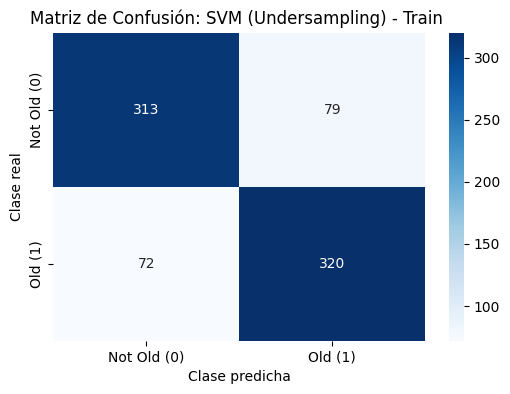

--- SVM (Undersampling) - Test Set ---
Accuracy: 0.8098
Recall: 0.8673
F1 Score: 0.5167


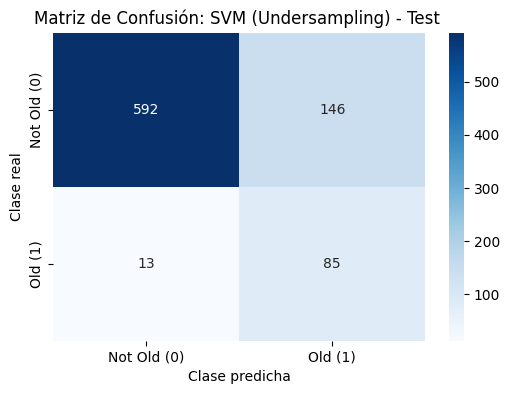

In [110]:
from sklearn.svm import SVC

# Entrenamiento de SVM con undersampling
svm_undersampled = SVC(random_state=24)
svm_undersampled.fit(X_train_undersampled, y_train_undersampled)

y_pred_svm_us_train = svm_undersampled.predict(X_train_undersampled)
y_pred_svm_us_test = svm_undersampled.predict(X_test_processed)

# --- Metricas de rendimiento TRAIN (Undersampling) ---
record_metrics('SVM', 'Undersampling', 'Train', y_train_undersampled, y_pred_svm_us_train)
# --- Metricas de rendimiento TEST (Undersampling) ---
record_metrics('SVM', 'Undersampling', 'Test', y_test, y_pred_svm_us_test)

--- SVM (Oversampling) - Train Set ---
Accuracy: 0.8301
Recall: 0.8542
F1 Score: 0.8341


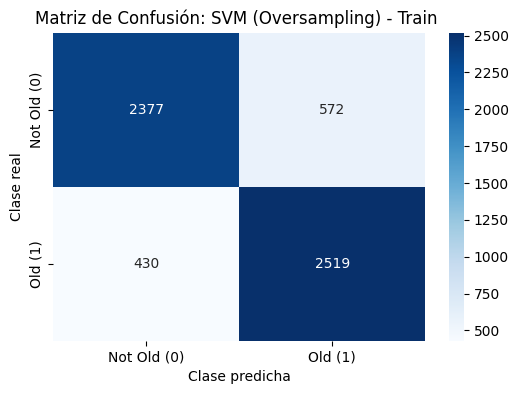

--- SVM (Oversampling) - Test Set ---
Accuracy: 0.8134
Recall: 0.8469
F1 Score: 0.5155


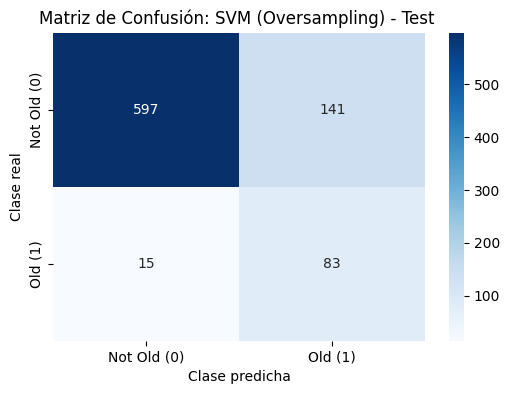

In [111]:
from sklearn.svm import SVC

# Entrenamiento de SVM con Oversampling
svm_oversampled = SVC(random_state=24)
svm_oversampled.fit(X_train_oversampled, y_train_oversampled)

y_pred_svm_os_train = svm_oversampled.predict(X_train_oversampled)
y_pred_svm_os_test = svm_oversampled.predict(X_test_processed)

# --- Metricas de rendimiento TRAIN (Oversampling) ---
record_metrics('SVM', 'Oversampling', 'Train', y_train_oversampled, y_pred_svm_os_train)
# --- Metricas de rendimiento TEST (Oversampling) ---
record_metrics('SVM', 'Oversampling', 'Test', y_test, y_pred_svm_os_test)

--- Random Forest (Undersampling) - Train Set ---
Accuracy: 1.0000
Recall: 1.0000
F1 Score: 1.0000


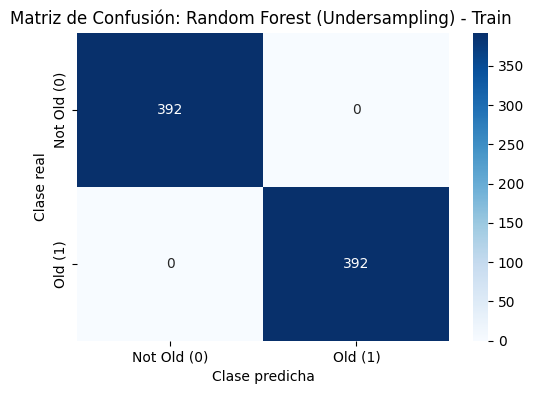

--- Random Forest (Undersampling) - Test Set ---
Accuracy: 0.7895
Recall: 0.8265
F1 Score: 0.4793


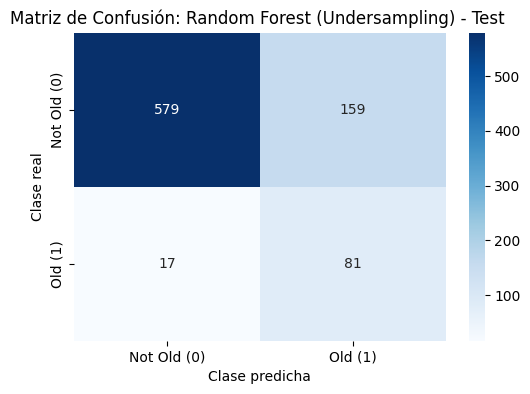

In [112]:
from sklearn.ensemble import RandomForestClassifier

# Entrenamiento de Random forest con undersampling
rf_undersampled = RandomForestClassifier(random_state=24)
rf_undersampled.fit(X_train_undersampled, y_train_undersampled)

y_pred_rf_us_train = rf_undersampled.predict(X_train_undersampled)
y_pred_rf_us_test = rf_undersampled.predict(X_test_processed)

# --- Metricas de rendimiento TRAIN (Undersampling) ---
record_metrics('Random Forest', 'Undersampling', 'Train', y_train_undersampled, y_pred_rf_us_train)
# --- Metricas de rendimiento TEST (Undersampling) ---
record_metrics('Random Forest', 'Undersampling', 'Test', y_test, y_pred_rf_us_test)



--- Random Forest (Oversampling) - Train Set ---
Accuracy: 1.0000
Recall: 1.0000
F1 Score: 1.0000


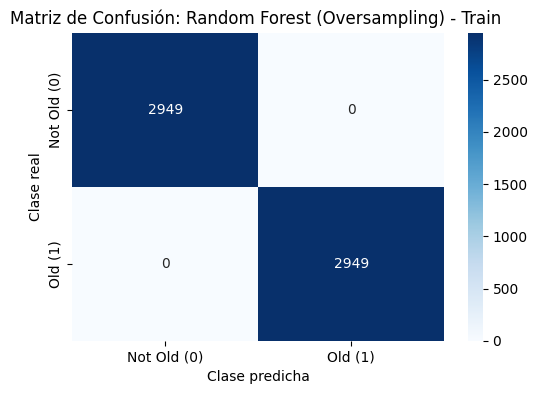

--- Random Forest (Oversampling) - Test Set ---
Accuracy: 0.8911
Recall: 0.3776
F1 Score: 0.4485


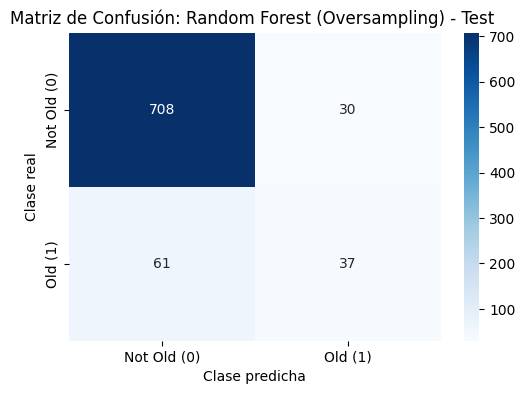

In [113]:
from sklearn.ensemble import RandomForestClassifier

# Entrenamiento de Random forest con oversampling
rf_oversampled = RandomForestClassifier(random_state=24)
rf_oversampled.fit(X_train_oversampled, y_train_oversampled)

y_pred_rf_os_train = rf_oversampled.predict(X_train_oversampled)
y_pred_rf_os_test = rf_oversampled.predict(X_test_processed)

# --- Metricas de rendimiento TRAIN (Oversampling) ---
record_metrics('Random Forest', 'Oversampling', 'Train', y_train_oversampled, y_pred_rf_os_train)
# --- Metricas de rendimiento TEST (Oversampling) ---
record_metrics('Random Forest', 'Oversampling', 'Test', y_test, y_pred_rf_os_test)



In [114]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

rf_tuned = RandomForestClassifier(random_state=24)
grid_search = GridSearchCV(estimator=rf_tuned, param_grid=param_grid, scoring='recall', cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train_oversampled, y_train_oversampled)

print("Mejores parámetros encontrados:", grid_search.best_params_)
best_rf_oversampled = grid_search.best_estimator_

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Mejores parámetros encontrados: {'max_depth': 15, 'min_samples_leaf': 1}


--- Random Forest (OverS - GridSearch) - Train Set ---
Accuracy: 0.9995
Recall: 1.0000
F1 Score: 0.9995


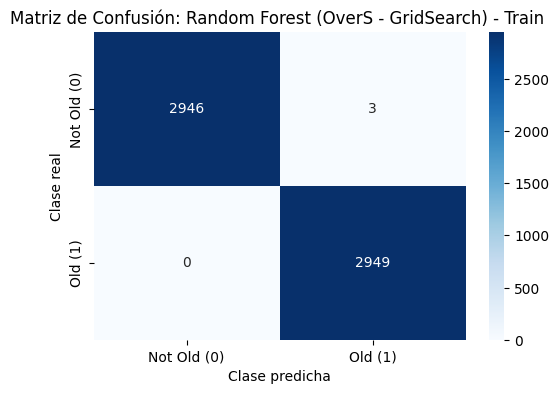

--- Random Forest (OverS - GridSearch) - Test Set ---
Accuracy: 0.8935
Recall: 0.4592
F1 Score: 0.5028


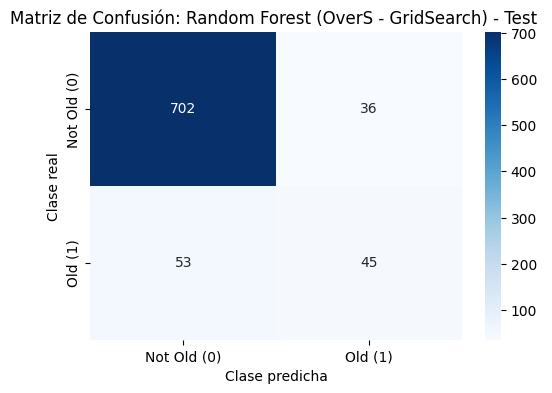

In [116]:
from sklearn.ensemble import RandomForestClassifier

y_pred_rf_tuned_os_train = best_rf_oversampled.predict(X_train_oversampled)
y_pred_rf_tuned_os_test = best_rf_oversampled.predict(X_test_processed)

# --- Metricas de rendimiento TRAIN (OverS - GridSearch) ---
record_metrics('Random Forest', 'OverS - GridSearch', 'Train', y_train_oversampled, y_pred_rf_tuned_os_train)
# --- Metricas de rendimiento TRAIN (OverS - GridSearch) ---
record_metrics('Random Forest', 'OverS - GridSearch', 'Test', y_test, y_pred_rf_tuned_os_test)


In [117]:
from imblearn.over_sampling import SMOTE

# Uso de SMOTE en el modelo
sm = SMOTE(random_state=24)
X_train_smoted, y_train_smoted = sm.fit_resample(X_train_processed, y_train_original)

print("Distribución de la variable objetivo después de SMOTE en el conjunto de entrenamiento:")
print(pd.Series(y_train_smoted).value_counts())

Distribución de la variable objetivo después de SMOTE en el conjunto de entrenamiento:
old
0    2949
1    2949
Name: count, dtype: int64


--- Logistic Regression (SMOTE) - Train Set ---
Accuracy: 0.8094
Recall: 0.7969
F1 Score: 0.8070


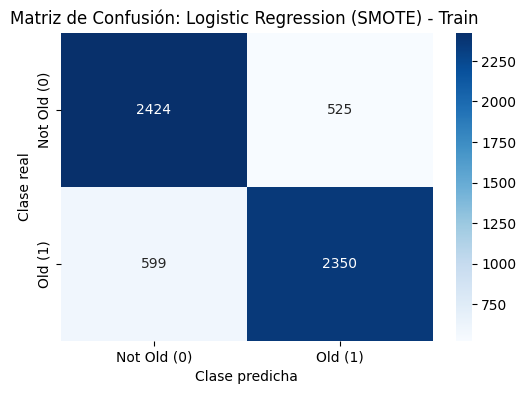

--- Logistic Regression (SMOTE) - Test Set ---
Accuracy: 0.8313
Recall: 0.8673
F1 Score: 0.5466


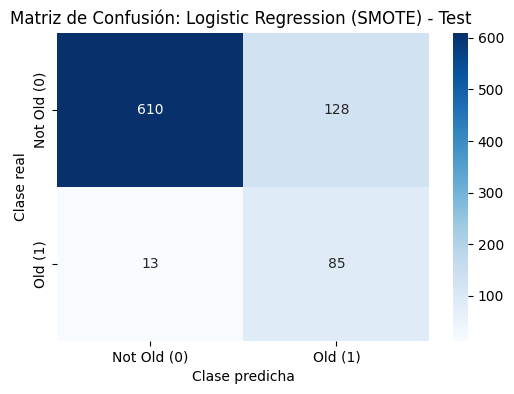

In [ ]:
from sklearn.linear_model import LogisticRegression

# Entrenmiento de Regresion Logistica con SMOTE
lr_smoted = LogisticRegression(random_state=24, solver='liblinear')
lr_smoted.fit(X_train_smoted, y_train_smoted)

y_pred_lr_smoted_train = lr_smoted.predict(X_train_smoted)
y_pred_lr_smoted_test = lr_smoted.predict(X_test_processed)

# --- Métricas de rendimiento TRAIN (SMOTE) ---
record_metrics('Logistic Regression', 'SMOTE', 'Train', y_train_smoted, y_pred_lr_smoted_train)
# --- Métricas de rendimiento TEST (SMOTE) ---
record_metrics('Logistic Regression', 'SMOTE', 'Test', y_test, y_pred_lr_smoted_test)

--- SVM (SMOTE) - Train Set ---
Accuracy: 0.8450
Recall: 0.8878
F1 Score: 0.8514


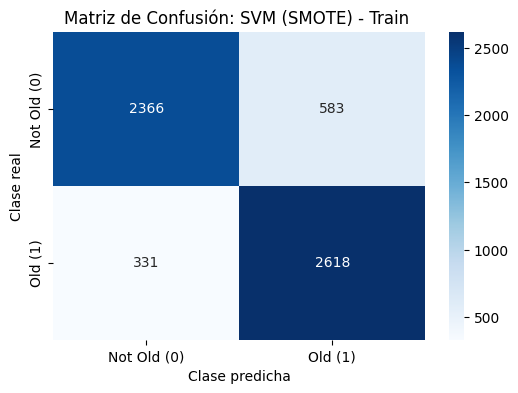

--- SVM (SMOTE) - Test Set ---
Accuracy: 0.8110
Recall: 0.8571
F1 Score: 0.5153


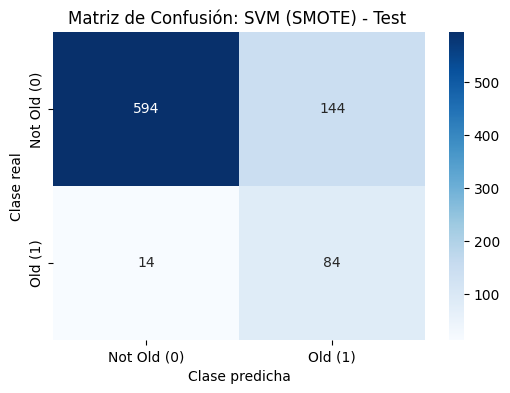

In [118]:
from sklearn.svm import SVC

# Entrenamiento de SVM con SMOTE
svm_smoted = SVC(random_state=24)
svm_smoted.fit(X_train_smoted, y_train_smoted)

y_pred_svm_smoted_train = svm_smoted.predict(X_train_smoted)
y_pred_svm_smoted_test = svm_smoted.predict(X_test_processed)

# --- Métricas de rendimiento TRAIN (SMOTE) ---
record_metrics('SVM', 'SMOTE', 'Train', y_train_smoted, y_pred_svm_smoted_train)
# --- Métricas de rendimiento TEST (SMOTE) ---
record_metrics('SVM', 'SMOTE', 'Test', y_test, y_pred_svm_smoted_test)


--- Random Forest (SMOTE) - Train Set ---
Accuracy: 1.0000
Recall: 1.0000
F1 Score: 1.0000


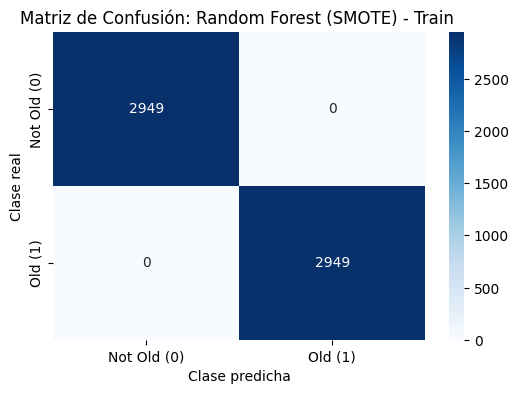

--- Random Forest (SMOTE) - Test Set ---
Accuracy: 0.8768
Recall: 0.5714
F1 Score: 0.5209


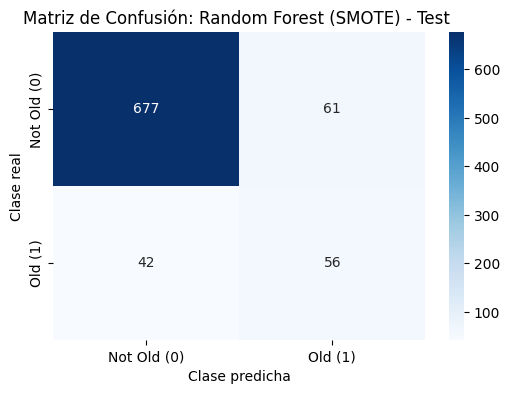

In [119]:
from sklearn.ensemble import RandomForestClassifier

# Entrenamiento de Random Forest con SMOTE
rf_smoted = RandomForestClassifier(random_state=24)
rf_smoted.fit(X_train_smoted, y_train_smoted)

y_pred_rf_smoted_train = rf_smoted.predict(X_train_smoted)
y_pred_rf_smoted_test = rf_smoted.predict(X_test_processed)

# --- Métricas de rendimiento TRAIN (SMOTE) ---
record_metrics('Random Forest', 'SMOTE', 'Train', y_train_smoted, y_pred_rf_smoted_train)
# --- Métricas de rendimiento TEST (SMOTE) ---
record_metrics('Random Forest', 'SMOTE', 'Test', y_test, y_pred_rf_smoted_test)



In [120]:

results_df = pd.DataFrame(all_evaluation_results)
results_df_styled = results_df.style.set_properties(**{'text-align': 'center'}).set_table_styles([dict(selector='th', props=[('text-align', 'center')])])

print("\n### Tabla Resumen de Métricas de Evaluación por Modelo y Estrategia de Balanceo\n")

display(results_df_styled)



### Tabla Resumen de Métricas de Evaluación por Modelo y Estrategia de Balanceo



,Model,Sampling,Set,Accuracy,Recall,F1 Score
0,Regresion Logistica,Solo,Entrenamiento,0.900928,0.290816,0.407871
1,Regresion Logistica,Solo,Test,0.898325,0.255102,0.370370
2,SVM,Solo,Train,0.897037,0.147959,0.252174
3,SVM,Solo,Test,0.886364,0.132653,0.214876
4,Random Forest,Solo,Train,1.000000,1.000000,1.000000
5,Random Forest,Solo,Test,0.895933,0.285714,0.391608
6,Logistic Regression,Undersampling,Train,0.785714,0.775510,0.783505
7,Logistic Regression,Undersampling,Test,0.824163,0.836735,0.527331
8,Logistic Regression,Oversampling,Train,0.792302,0.770431,0.787658
9,Logistic Regression,Oversampling,Test,0.836124,0.867347,0.553746



#### Modelos con mayor recall
*   Logistic Regression con Oversampling: Recall de 0.8673
*   SVM con Undersampling: Recall de 0.8673
*   Logistic Regression con SMOTE: Recall de 0.8673

#### Mejor Modelo por cada estratgia de Balanceo:
 - Sin Balanceo ('Solo'): El mejor modelo fue Random Forest con un Recall de 0.2857.
 - Undersampling: El mejor modelo fue SVM con un Recall de 0.8673.
 - Oversampling: El mejor modelo fue regresion logistica con un Recall de 0.8673.
 - SMOTE: El mejor modelo fue regresion logistica con un Recall de 0.8673.